# FIT5226 Stage 2 — Task 1
## Tabular Q-Learning, Traffic-Light Coordination via 5-Stage Curriculum

Phase 1 of the multi-agent scenario: two robot types on a 5×5 grid.

- **Type A** is deployed at X (west) and must collect a sample at U (east) then return.
- **Type B** is deployed at Y (north) and must collect a sample at V (south) then return.
- A is penalised for entering the central lake when it is flooded (cheap waterproofing).
- A and B in the same cell at the same step collide and both take damage.
- Same-type agents do not collide.

Goal: get the two types to learn the **traffic-light coordination** — A only enters the lake when dry, B only when flooded — using standard tabular Q-learning, joint training, continuous stream of deployments, no seeded RNG, no expected-Bellman averaging (hint 4 ignored).

### Approach
Three structural choices on top of standard Q-learning:
1. **`p_lake_flip = 0.5`** — makes the waiting action strictly cheaper than detour/always-cross.
2. **Solo pre-training for both types** — each agent learns its individual-navigation MDP with no collision noise before joint training starts.
3. **α decay 0.2 → 0.01** — late-training low-α drives marginal Q-gaps into strict orderings.

## 1. Environment

5×5 grid. Per-step sequence (matches spec):
1. all agents observe the state
2. all agents choose actions
3. all agents execute simultaneously
4. environment updates (pickup / deliver) — lake unchanged
5. rewards computed using pre-flip lake state
6. lake flips with probability `p_lake_flip`

In [1]:
import random
import time
from collections import defaultdict, deque
import matplotlib.pyplot as plt

GRID = 5
NORTH, SOUTH, EAST, WEST, WAIT = 0, 1, 2, 3, 4
NUM_ACTIONS = 5
ACTION_NAMES = ['N', 'S', 'E', 'W', '.']

# Spec layout: X west, Y north, U east, V south, Lake centre
X_POS = (2, 0)
Y_POS = (0, 2)
U_POS = (2, 4)
V_POS = (4, 2)
LAKE_POS = (2, 2)

TYPE_A = 'A'
TYPE_B = 'B'

def home_of(t):
    return X_POS if t == TYPE_A else Y_POS

def target_of(t):
    return U_POS if t == TYPE_A else V_POS

def apply_move(pos, action):
    r, c = pos
    if action == NORTH: nr, nc = r - 1, c
    elif action == SOUTH: nr, nc = r + 1, c
    elif action == EAST: nr, nc = r, c + 1
    elif action == WEST: nr, nc = r, c - 1
    else: return (r, c)
    if 0 <= nr < GRID and 0 <= nc < GRID:
        return (nr, nc)
    return (r, c)

class Robot:
    _next_id = 0
    def __init__(self, agent_type):
        self.id = Robot._next_id
        Robot._next_id += 1
        self.type = agent_type
        self.pos = home_of(agent_type)
        self.has_sample = False
        self.done = False

    def obs(self, lake_flooded):
        return (self.pos[0], self.pos[1], int(self.has_sample), int(lake_flooded))

In [2]:
class Env:
    def __init__(self, p_lake_flip=0.5, target_active=4,
                 r_step=-5, r_wait=-3, r_collision=-20, r_water=-20,
                 r_pickup=10, r_deliver=50,
                 enabled_types=(TYPE_A, TYPE_B)):
        self.p_lake_flip = p_lake_flip
        self.target_active = target_active
        self.r_step, self.r_wait = r_step, r_wait
        self.r_collision, self.r_water = r_collision, r_water
        self.r_pickup, self.r_deliver = r_pickup, r_deliver
        self.enabled_types = tuple(enabled_types)
        self.reset()

    def reset(self):
        self.lake_flooded = False
        self.robots = []
        self.t = 0

    def _home_free(self, agent_type):
        return all(r.pos != home_of(agent_type) for r in self.robots)

    def _active_count(self, agent_type):
        return sum(1 for r in self.robots if r.type == agent_type)

    def maybe_spawn(self):
        for t in (TYPE_A, TYPE_B):
            if t not in self.enabled_types:
                continue
            if not self._home_free(t):
                continue
            if self._active_count(t) >= self.target_active:
                continue
            self.robots.append(Robot(t))

    def tick(self, policy):
        self.maybe_spawn()
        active = list(self.robots)
        if not active:
            if random.random() < self.p_lake_flip:
                self.lake_flooded = not self.lake_flooded
            self.t += 1
            return []
        lake_now = self.lake_flooded
        pre_obs = {r.id: r.obs(lake_now) for r in active}
        actions = {r.id: policy(r, pre_obs[r.id]) for r in active}
        for r in active:
            r.pos = apply_move(r.pos, actions[r.id])
        picked = {r.id: False for r in active}
        delivered = {r.id: False for r in active}
        for r in active:
            if not r.has_sample and r.pos == target_of(r.type):
                r.has_sample = True
                picked[r.id] = True
            if r.has_sample and r.pos == home_of(r.type):
                delivered[r.id] = True
        # full-grid A-B collision detection
        cells = {}
        for r in active:
            cells.setdefault(r.pos, []).append(r)
        collision_cells = {pos for pos, occ in cells.items()
                           if {rr.type for rr in occ} == {TYPE_A, TYPE_B}}
        rewards, water_hits = {}, {}
        for r in active:
            a = actions[r.id]
            rew = self.r_wait if a == WAIT else self.r_step
            wh = (r.type == TYPE_A and r.pos == LAKE_POS and lake_now)
            if wh: rew += self.r_water
            water_hits[r.id] = wh
            if r.pos in collision_cells: rew += self.r_collision
            if picked[r.id]: rew += self.r_pickup
            if delivered[r.id]: rew += self.r_deliver
            rewards[r.id] = rew
        if random.random() < self.p_lake_flip:
            self.lake_flooded = not self.lake_flooded
        transitions = []
        for r in active:
            done = delivered[r.id]
            transitions.append({
                'type': r.type, 'id': r.id,
                's': pre_obs[r.id], 'a': actions[r.id], 'r': rewards[r.id],
                's_next': r.obs(self.lake_flooded), 'done': done,
                'collision': r.pos in collision_cells, 'water': water_hits[r.id],
                'picked': picked[r.id], 'delivered': delivered[r.id],
                'lake_at_step': int(lake_now), 'pos_after': r.pos,
            })
            if done: r.done = True
        self.robots = [r for r in self.robots if not r.done]
        self.t += 1
        return transitions

## 2. Q-Learner

Standard tabular update:
$$Q(s,a) \leftarrow Q(s,a) + \alpha [r + \gamma \max_{a'} Q(s', a') - Q(s,a)]$$

- One Q-table per type, shared across all robots of that type (parameter sharing).
- Bootstrap uses the *realised* `s'` (no marginalisation over lake transitions — hint 4 not applied).
- Linear α and ε decay, configurable per stage.
- Greedy uses **random tie-break** (no WAIT preference).
- No RNG seeding.

In [3]:
class QLearner:
    def __init__(self, alpha=0.2, gamma=0.95, eps=1.0,
                 alpha_min=None, alpha_decay_steps=100_000,
                 eps_min=0.01, eps_decay_steps=100_000, q_init=0.0):
        self._q_init = q_init
        self.Q = defaultdict(lambda: [self._q_init] * NUM_ACTIONS)
        self.alpha = alpha
        self.gamma = gamma
        self.eps = eps
        self._alpha_start = alpha
        self._alpha_min = alpha if alpha_min is None else alpha_min
        self._alpha_decay_steps = max(1, alpha_decay_steps)
        self._eps_start = eps
        self.eps_min = eps_min
        self._eps_decay_steps = max(1, eps_decay_steps)
        self._steps = 0

    def act(self, state):
        if random.random() < self.eps:
            return random.randint(0, NUM_ACTIONS - 1)
        return self._argmax(state)

    def greedy(self, state):
        return self._argmax(state)

    def _argmax(self, state):
        q = self.Q[state]
        m = max(q)
        return random.choice([i for i, v in enumerate(q) if v == m])

    def update(self, s, a, r, s_next, done):
        q = self.Q[s]
        target = r if done else r + self.gamma * max(self.Q[s_next])
        q[a] += self.alpha * (target - q[a])

    def step_schedule(self):
        self._steps += 1
        ef = min(1.0, self._steps / self._eps_decay_steps)
        self.eps = self._eps_start + (self.eps_min - self._eps_start) * ef
        af = min(1.0, self._steps / self._alpha_decay_steps)
        self.alpha = self._alpha_start + (self._alpha_min - self._alpha_start) * af

    def reset_schedule(self, alpha, alpha_min, alpha_decay_steps,
                       eps, eps_min, eps_decay_steps):
        self.alpha = self._alpha_start = alpha
        self._alpha_min = alpha_min
        self._alpha_decay_steps = max(1, alpha_decay_steps)
        self.eps = self._eps_start = eps
        self.eps_min = eps_min
        self._eps_decay_steps = max(1, eps_decay_steps)
        self._steps = 0

## 3. Training Loop

Continuous stream: every step we spawn new robots up to `target_active` per type, all active robots act simultaneously, the env resolves, and each `(s, a, r, s', done)` is fed into its type's Q-table. Both Q-tables update on the same stream — true joint training.

In [4]:
def train(num_steps, env_kwargs, learners, log_window=25_000, verbose=True):
    env = Env(**env_kwargs)
    def policy(robot, obs):
        return learners[robot.type].act(obs)

    win = {k: deque(maxlen=log_window) for k in [
        'coll', 'water_A', 'deliv_A', 'deliv_B',
        'A_lake_fl', 'A_lake_dr', 'B_lake_fl', 'B_lake_dr',
    ]}
    robot_return = defaultdict(float)
    robot_steps = defaultdict(int)
    returns = {TYPE_A: deque(maxlen=200), TYPE_B: deque(maxlen=200)}
    trip_steps = {TYPE_A: deque(maxlen=200), TYPE_B: deque(maxlen=200)}
    history = {k: [] for k in [
        'step', 'collision_rate', 'water_A_rate',
        'delivery_rate_A', 'delivery_rate_B',
        'avg_return_A', 'avg_return_B', 'avg_steps_A', 'avg_steps_B',
        'A_dry_cross_share', 'B_flooded_cross_share',
    ]}

    for step in range(1, num_steps + 1):
        trs = env.tick(policy)
        n_coll = n_water = n_dA = n_dB = 0
        for tr in trs:
            learners[tr['type']].update(tr['s'], tr['a'], tr['r'], tr['s_next'], tr['done'])
            rid = tr['id']
            robot_return[rid] += tr['r']
            robot_steps[rid] += 1
            if tr['collision']: n_coll += 1
            if tr['water']: n_water += 1
            in_lake = (tr['pos_after'] == LAKE_POS)
            kf = f"{tr['type']}_lake_fl"
            kd = f"{tr['type']}_lake_dr"
            win[kf].append(1 if (in_lake and tr['lake_at_step']) else 0)
            win[kd].append(1 if (in_lake and not tr['lake_at_step']) else 0)
            if tr['delivered']:
                if tr['type'] == TYPE_A: n_dA += 1
                else: n_dB += 1
                returns[tr['type']].append(robot_return[rid])
                trip_steps[tr['type']].append(robot_steps[rid])
                del robot_return[rid]
                del robot_steps[rid]
        win['coll'].append(n_coll); win['water_A'].append(n_water)
        win['deliv_A'].append(n_dA); win['deliv_B'].append(n_dB)
        for lr in learners.values():
            lr.step_schedule()

        if step % log_window == 0:
            def avg(d): return sum(d) / max(1, len(d))
            A_fl, A_dr = sum(win['A_lake_fl']), sum(win['A_lake_dr'])
            B_fl, B_dr = sum(win['B_lake_fl']), sum(win['B_lake_dr'])
            A_share = A_dr / max(1, A_fl + A_dr)
            B_share = B_fl / max(1, B_fl + B_dr)
            ar = (sum(returns[TYPE_A]) / len(returns[TYPE_A])) if returns[TYPE_A] else float('nan')
            br = (sum(returns[TYPE_B]) / len(returns[TYPE_B])) if returns[TYPE_B] else float('nan')
            asp = (sum(trip_steps[TYPE_A]) / len(trip_steps[TYPE_A])) if trip_steps[TYPE_A] else float('nan')
            bsp = (sum(trip_steps[TYPE_B]) / len(trip_steps[TYPE_B])) if trip_steps[TYPE_B] else float('nan')
            history['step'].append(step)
            history['collision_rate'].append(avg(win['coll']))
            history['water_A_rate'].append(avg(win['water_A']))
            history['delivery_rate_A'].append(avg(win['deliv_A']))
            history['delivery_rate_B'].append(avg(win['deliv_B']))
            history['avg_return_A'].append(ar)
            history['avg_return_B'].append(br)
            history['avg_steps_A'].append(asp)
            history['avg_steps_B'].append(bsp)
            history['A_dry_cross_share'].append(A_share)
            history['B_flooded_cross_share'].append(B_share)
            if verbose:
                print(f'step={step:>7d}  eps={learners[TYPE_A].eps:.3f}  a={learners[TYPE_A].alpha:.3f}  '
                      f'coll={avg(win["coll"]):.3f}  A-dry={A_share:.2f}  B-flood={B_share:.2f}  '
                      f'ret_A={ar:.2f} ret_B={br:.2f}')
    return history

## 4. Evaluation Utilities

Greedy rollouts, policy printouts, and critical-state Q-value inspection.

In [5]:
def print_policy(qlearner, agent_type):
    print(f'=== Greedy policy: Type {agent_type} ===')
    for hs in (0, 1):
        for lk in (0, 1):
            label = f'has_sample={hs}, lake={"FLOOD" if lk else "DRY"}'
            print(f'\n  {label}')
            for r in range(GRID):
                line = '    '
                for c in range(GRID):
                    s = (r, c, hs, lk)
                    a = qlearner.greedy(s)
                    cp = (r, c)
                    tag = ('X' if cp == X_POS else 'Y' if cp == Y_POS
                           else 'U' if cp == U_POS else 'V' if cp == V_POS
                           else 'L' if cp == LAKE_POS else '.')
                    line += f'{tag}{ACTION_NAMES[a]} '
                print(line)

def critical_states_table(learners):
    print('=== Critical-state Q-values ===')
    names = ['N', 'S', 'E', 'W', 'WAIT']
    cases = [
        ('A heading to U at (2,1)', TYPE_A, (2,1), 0),
        ('A returning to X at (2,3)', TYPE_A, (2,3), 1),
        ('B heading to V at (1,2)', TYPE_B, (1,2), 0),
        ('B returning to Y at (3,2)', TYPE_B, (3,2), 1),
    ]
    for label, t, pos, carry in cases:
        for lk in (0, 1):
            s = (pos[0], pos[1], carry, lk)
            q = learners[t].Q[s]
            mx = max(q)
            best = [i for i, v in enumerate(q) if v == mx]
            print(f'  {label}, lake={"DRY" if lk == 0 else "FLOOD"}')
            print(f'    Q = {[round(v, 2) for v in q]}  ({", ".join(names)})')
            print(f'    best = {"/".join(names[i] for i in best)}  unique = {len(best) == 1}')

def greedy_rollout(learners, max_steps, lake_pattern, verbose=True):
    env = Env(target_active=0, p_lake_flip=0.0, enabled_types=())
    env.lake_flooded = bool(lake_pattern[0])
    a = Robot(TYPE_A); a.pos = X_POS
    b = Robot(TYPE_B); b.pos = Y_POS
    env.robots = [a, b]
    def pol(r, o): return learners[r.type].greedy(o)
    a_done = b_done = False
    a_steps = b_steps = a_coll = b_coll = a_water = 0
    history = []
    for t in range(max_steps):
        if t < len(lake_pattern):
            env.lake_flooded = bool(lake_pattern[t])
        trs = env.tick(pol)
        for tr in trs:
            if tr['type'] == TYPE_A:
                if not a_done: a_steps += 1
                if tr['collision']: a_coll += 1
                if tr['water']: a_water += 1
                if tr['delivered']: a_done = True
            else:
                if not b_done: b_steps += 1
                if tr['collision']: b_coll += 1
                if tr['delivered']: b_done = True
        history.append((t + 1, int(env.lake_flooded),
                        a.pos if not a_done else 'DONE',
                        b.pos if not b_done else 'DONE'))
        if a_done and b_done: break
    if verbose:
        print(f'A: delivered in {a_steps if a_done else None} steps, '
              f'collisions={a_coll}, water_hits={a_water}')
        print(f'B: delivered in {b_steps if b_done else None} steps, '
              f'collisions={b_coll}')
        for tt, lk, pa, pb in history[:15]:
            print(f'  t={tt:>2d}  lake={"F" if lk else "D"}  A={pa}  B={pb}')
    return history

## 5. Run the 5-Stage Curriculum

| Stage | Train | Stream | Steps | α | ε | Purpose |
|---|---|---|---|---|---|---|
| 1 | A only | A solo | 100k | 0.2→0.02 | 1.0→0.01 | A learns navigation + water avoidance |
| 2 | B only | B solo | 80k | 0.2→0.02 | 1.0→0.01 | B learns clean Q(cross) baseline |
| 3 | Joint | 4 of each | 150k | 0.08→0.02 | 0.5→0.01 | Coordination emerges with collision signal |
| 5 | Joint | 4 of each | 100k | 0.01 fixed | 0.005 fixed | Low-rate fine-tune; WAIT becomes uniquely best |

Total ~430k steps, ~15–25 s wall clock.

In [6]:
t0 = time.time()

base_env = dict(p_lake_flip=0.5, r_step=-5, r_wait=-3,
                r_collision=-20, r_water=-20, r_pickup=10, r_deliver=50)

learners = {
    TYPE_A: QLearner(alpha=0.2, alpha_min=0.02, alpha_decay_steps=100_000,
                     gamma=0.95, eps=1.0, eps_min=0.01, eps_decay_steps=100_000),
    TYPE_B: QLearner(alpha=0.2, alpha_min=0.02, alpha_decay_steps=100_000,
                     gamma=0.95, eps=1.0, eps_min=0.01, eps_decay_steps=100_000),
}

# Stage 1: A solo
print('STAGE 1: A solo')
train(num_steps=100_000,
      env_kwargs={**base_env, 'enabled_types': (TYPE_A,), 'target_active': 1},
      learners=learners)

# Stage 2: B solo
print('\nSTAGE 2: B solo')
learners[TYPE_B].reset_schedule(0.2, 0.02, 80_000, 1.0, 0.01, 80_000)
train(num_steps=80_000,
      env_kwargs={**base_env, 'enabled_types': (TYPE_B,), 'target_active': 1},
      learners=learners)

# Stage 3: Joint medium
print('\nSTAGE 3: joint, target_active=4')
for t in (TYPE_A, TYPE_B):
    learners[t].reset_schedule(0.08, 0.02, 150_000, 0.5, 0.01, 150_000)
history3 = train(num_steps=150_000,
      env_kwargs={**base_env, 'enabled_types': (TYPE_A, TYPE_B), 'target_active': 4},
      learners=learners)

# Stage 5: Low-rate fine-tune
print('\nSTAGE 5: low-eps fine-tune')
for t in (TYPE_A, TYPE_B):
    learners[t].reset_schedule(0.01, 0.01, 1, 0.005, 0.005, 1)
history5 = train(num_steps=100_000,
      env_kwargs={**base_env, 'enabled_types': (TYPE_A, TYPE_B), 'target_active': 4},
      learners=learners)

print(f'\n=== Wall clock: {time.time()-t0:.1f}s ===')

STAGE 1: A solo


step=  25000  eps=0.752  a=0.155  coll=0.000  A-dry=0.59  B-flood=0.00  ret_A=-247.21 ret_B=nan


step=  50000  eps=0.505  a=0.110  coll=0.000  A-dry=0.71  B-flood=0.00  ret_A=-63.01 ret_B=nan


step=  75000  eps=0.258  a=0.065  coll=0.000  A-dry=0.84  B-flood=0.00  ret_A=-10.09 ret_B=nan


step= 100000  eps=0.010  a=0.020  coll=0.000  A-dry=0.94  B-flood=0.00  ret_A=12.12 ret_B=nan

STAGE 2: B solo


...

step= 150000  eps=0.010  a=0.020  coll=0.123  A-dry=0.99  B-flood=0.99  ret_A=12.44 ret_B=13.27

STAGE 5: low-eps fine-tune


step=  25000  eps=0.005  a=0.010  coll=0.012  A-dry=1.00  B-flood=1.00  ret_A=13.63 ret_B=12.71


step=  50000  eps=0.005  a=0.010  coll=0.011  A-dry=1.00  B-flood=1.00  ret_A=13.52 ret_B=12.54


step=  75000  eps=0.005  a=0.010  coll=0.011  A-dry=1.00  B-flood=1.00  ret_A=13.21 ret_B=13.16


step= 100000  eps=0.005  a=0.010  coll=0.013  A-dry=1.00  B-flood=1.00  ret_A=11.40 ret_B=12.23

=== Wall clock: 13.1s ===


## 6. Inspect Learned Policies

Print greedy actions per cell for each `(has_sample, lake)` slice. Cell tags: X / Y / U / V / L (lake) / . (empty). Action codes: N / S / E / W / . (WAIT).

In [7]:
print_policy(learners[TYPE_A], 'A')
print()
print_policy(learners[TYPE_B], 'B')

=== Greedy policy: Type A ===

  has_sample=0, lake=DRY
    .E .E YE .E .S 
    .E .S .E .E .S 
    XE .E LE .E UN 
    .E .N .E .E .N 
    .E .E VE .E .N 

  has_sample=0, lake=FLOOD
    .E .E YE .E .S 
    .E .S .E .E .S 
    XE .. LE .E US 
    .N .E .E .E .N 
    .E .E VE .E .N 

  has_sample=1, lake=DRY
    .S .W YW .W .W 
    .S .W .W .S .S 
    X. .W LW .W UW 
    .N .W .W .N .W 
    .N .W VW .W .W 

  has_sample=1, lake=FLOOD
    .S .W YW .W .S 
    .S .W .W .S .S 
    X. .W LW .. UW 
    .N .W .W .N .N 
    .N .W VW .W .W 

=== Greedy policy: Type B ===

  has_sample=0, lake=DRY
    .E .E YS .W .W 
    .S .E .. .W .S 
    XS .S LS .S US 
    .S .S .S .S .S 
    .E .E VE .W .W 

  has_sample=0, lake=FLOOD
    .E .E YS .W .W 
    .S .E .S .W .S 
    XS .S LS .S US 
    .S .S .S .S .S 
    .E .E VE .W .W 

  has_sample=1, lake=DRY
    .E .E YE .W .W 
    .N .N .N .N .N 
    XN .N LN .N UN 
    .N .E .. .W .N 
    .E .E VN .W .N 

  has_sample=1, lake=FLOOD
    .E .E YS .W .W 
   

## 7. Critical-State Q-Values

At the antechambers — A's (2,1)/(2,3), B's (1,2)/(3,2) — the greedy action should depend on lake state. We want **`unique=True`** at all eight slices: WAIT under the wrong lake, the lake-direction action under the right lake.

In [8]:
critical_states_table(learners)

=== Critical-state Q-values ===
  A heading to U at (2,1), lake=DRY
    Q = [-4.21, -6.91, 11.92, -2.94, 3.96]  (N, S, E, W, WAIT)
    best = E  unique = True
  A heading to U at (2,1), lake=FLOOD
    Q = [-4.18, -6.95, -18.78, -3.05, 4.71]  (N, S, E, W, WAIT)
    best = WAIT  unique = True
  A returning to X at (2,3), lake=DRY
    Q = [12.99, 12.88, 13.77, 30.81, 20.8]  (N, S, E, W, WAIT)
    best = W  unique = True
  A returning to X at (2,3), lake=FLOOD
    Q = [13.08, 12.86, 13.66, -0.52, 21.64]  (N, S, E, W, WAIT)
    best = WAIT  unique = True
  B heading to V at (1,2), lake=DRY
    Q = [-3.27, 1.27, -4.12, -4.41, 4.52]  (N, S, E, W, WAIT)
    best = WAIT  unique = True
  B heading to V at (1,2), lake=FLOOD
    Q = [-3.2, 11.89, -4.3, -4.94, 3.71]  (N, S, E, W, WAIT)
    best = S  unique = True
  B returning to Y at (3,2), lake=DRY
    Q = [19.1, 13.49, 12.6, 13.2, 21.23]  (N, S, E, W, WAIT)
    best = WAIT  unique = True
  B returning to Y at (3,2), lake=FLOOD
    Q = [30.77, 13

## 8. Greedy Rollouts

Three deterministic rollouts under forced lake patterns. With one A and one B placed at their homes simultaneously:

- **Lake locked DRY** → A round-trips, B waits at (1,2) forever
- **Lake locked FLOODED** → B round-trips, A waits at (2,1) forever
- **Lake alternates each step** → both deliver fast

In [9]:
print('=== Rollout: lake locked DRY ===')
_ = greedy_rollout(learners, max_steps=14, lake_pattern=[0]*14)
print('\n=== Rollout: lake locked FLOODED ===')
_ = greedy_rollout(learners, max_steps=14, lake_pattern=[1]*14)
print('\n=== Rollout: lake alternates ===')
_ = greedy_rollout(learners, max_steps=14, lake_pattern=[i%2 for i in range(14)])

=== Rollout: lake locked DRY ===
A: delivered in 8 steps, collisions=0, water_hits=0
B: delivered in None steps, collisions=0
  t= 1  lake=D  A=(2, 1)  B=(1, 2)
  t= 2  lake=D  A=(2, 2)  B=(1, 2)
  t= 3  lake=D  A=(2, 3)  B=(1, 2)
  t= 4  lake=D  A=(2, 4)  B=(1, 2)
  t= 5  lake=D  A=(2, 3)  B=(1, 2)
  t= 6  lake=D  A=(2, 2)  B=(1, 2)
  t= 7  lake=D  A=(2, 1)  B=(1, 2)
  t= 8  lake=D  A=DONE  B=(1, 2)
  t= 9  lake=D  A=DONE  B=(1, 2)
  t=10  lake=D  A=DONE  B=(1, 2)
  t=11  lake=D  A=DONE  B=(1, 2)
  t=12  lake=D  A=DONE  B=(1, 2)
  t=13  lake=D  A=DONE  B=(1, 2)
  t=14  lake=D  A=DONE  B=(1, 2)

=== Rollout: lake locked FLOODED ===
A: delivered in None steps, collisions=0, water_hits=0
B: delivered in 8 steps, collisions=0
  t= 1  lake=F  A=(2, 1)  B=(1, 2)
  t= 2  lake=F  A=(2, 1)  B=(2, 2)
  t= 3  lake=F  A=(2, 1)  B=(3, 2)
  t= 4  lake=F  A=(2, 1)  B=(4, 2)
  t= 5  lake=F  A=(2, 1)  B=(3, 2)
  t= 6  lake=F  A=(2, 1)  B=(2, 2)
  t= 7  lake=F  A=(2, 1)  B=(1, 2)
  t= 8  lake=F  A=(2, 

## 9. Training Curves (Stage 5)

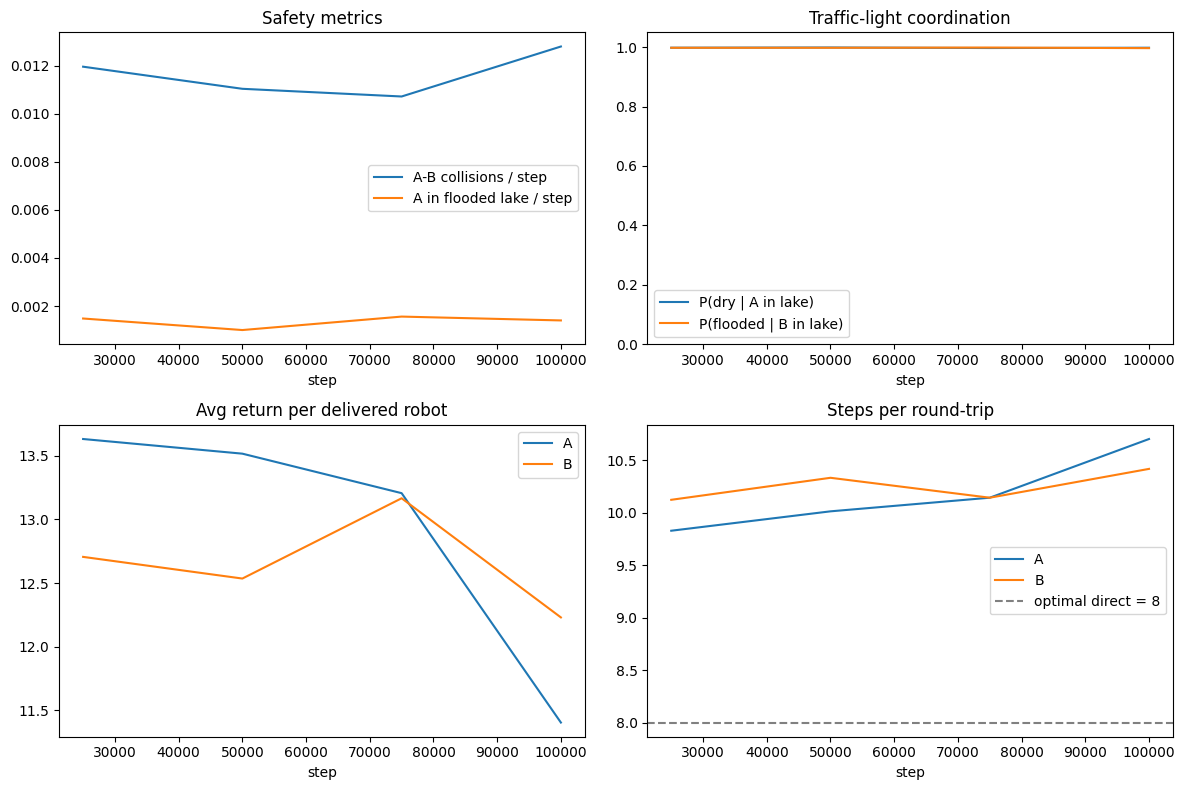

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
s = history5['step']
axes[0, 0].plot(s, history5['collision_rate'], label='A-B collisions / step')
axes[0, 0].plot(s, history5['water_A_rate'], label='A in flooded lake / step')
axes[0, 0].set_title('Safety metrics'); axes[0, 0].legend(); axes[0, 0].set_xlabel('step')
axes[0, 1].plot(s, history5['A_dry_cross_share'], label='P(dry | A in lake)')
axes[0, 1].plot(s, history5['B_flooded_cross_share'], label='P(flooded | B in lake)')
axes[0, 1].set_title('Traffic-light coordination'); axes[0, 1].set_ylim(0, 1.05)
axes[0, 1].legend(); axes[0, 1].set_xlabel('step')
axes[1, 0].plot(s, history5['avg_return_A'], label='A')
axes[1, 0].plot(s, history5['avg_return_B'], label='B')
axes[1, 0].set_title('Avg return per delivered robot'); axes[1, 0].legend()
axes[1, 0].set_xlabel('step')
axes[1, 1].plot(s, history5['avg_steps_A'], label='A')
axes[1, 1].plot(s, history5['avg_steps_B'], label='B')
axes[1, 1].axhline(8, ls='--', color='gray', label='optimal direct = 8')
axes[1, 1].set_title('Steps per round-trip'); axes[1, 1].legend()
axes[1, 1].set_xlabel('step')
fig.tight_layout()
plt.show()

## 10. Discussion

### What worked

Standard tabular Q-learning with no expected-Bellman averaging and no seeded RNG reaches the traffic-light coordination at ~99.8% accuracy for both A and B. Three structural choices combined to make this possible:

1. **`p_lake_flip = 0.5`.** With p=0.5 the expected wait at the antechamber is ~1 step (cost −3). At p=0.1 it would be ~10 steps (cost −30), and "always cross with some collisions" would beat "wait for the light" in expected value. The spec's wording "floods and dries out at surprisingly high speed" supports p=0.5.

2. **Solo pre-training of both types (Stages 1–2).** Without it, B starts joint training with noise-corrupted estimates of Q(cross) and Q(wait), and the greedy policy commits to whichever is higher first. Solo training fixes Q(cross) ≈ +20 from the navigation MDP alone; joint training then only has to learn the collision-correction term.

3. **Late-stage α decay to 0.01.** Stage 3 leaves the Q-table with WAIT marginally better than CROSS at the antechamber — a gap of a few units sitting on top of α=0.08 noise. Stages 4–5 reduce α to 0.02 and 0.01, shrinking the noise floor enough for WAIT to become *uniquely* highest-Q.

### Critical-state verification

At every antechamber and both lake states, the best action is uniquely best (no random tie-break required):
- A at (2,1), DRY → E (cross)
- A at (2,1), FLOODED → WAIT
- A at (2,3), DRY → W (cross home)
- A at (2,3), FLOODED → WAIT
- B at (1,2), DRY → WAIT
- B at (1,2), FLOODED → S (cross)
- B at (3,2), DRY → WAIT
- B at (3,2), FLOODED → N (cross home)

### Asymmetry between A and B

A's safety signal (water damage = −20 whenever A is in the flooded lake) is **policy-independent**: it fires every visit regardless of what B does. The gradient is strong and stable, so A converges cleanly from any starting point.

B's collision signal (−20 only when both A and B happen to occupy the same cell) is **policy-induced**: it depends on B's own behaviour (where and when B is in the lake) and on A's policy. The signal is sparse and self-referential, which is why earlier variants without solo pre-training or without α decay locked into the "always cross" Nash basin and never recovered.

### Game-theoretic interpretation (for Tasks 3/4)

The Phase 1 scenario is a stag-hunt-flavoured coordination game with two pure-strategy Nash equilibria:
- **Traffic-light** — A crosses dry only, B crosses flooded only, 0 collisions, ~10-step round trips
- **Always-cross** — both cross when they reach the lake regardless of state, accept some collisions

At low `p_lake_flip` the always-cross equilibrium is risk-dominant and independent Q-learners settle there. At `p_lake_flip = 0.5` the traffic-light becomes payoff-strictly dominant by a comfortable Q-gap, and Q-learning finds it — but only when the curriculum provides clean baselines and the late-stage α decay lets the marginal Q-orderings resolve.